**BEUST Léna**
_____________
# **Auto-Encoders**

In [1]:
import tensorflow as tf
import numpy as np
import gzip
import keras
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.models import Model
from keras.optimizers import RMSprop
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import metrics
from matplotlib import pyplot as plt

I0000 00:00:1778938803.527256  285508 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778938804.767787  285508 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778938809.881503  285508 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
def extract_data(filename, num_images):
    with gzip.open(filename) as bytestream:
        bytestream.read(16)
        buf = bytestream.read(28 * 28 * num_images)
        data = np.frombuffer(buf, dtype=np.uint8).astype(np.float32)
        data = data.reshape(num_images, 28,28)
        return data

def extract_labels(filename, num_images):
    with gzip.open(filename) as bytestream:
        bytestream.read(8)
        buf = bytestream.read(1 * num_images)
        labels = np.frombuffer(buf, dtype=np.uint8).astype(np.int64)
        return labels

# Create dictionary of target classes
label_dict = {
 0: 'A',
 1: 'B',
 2: 'C',
 3: 'D',
 4: 'E',
 5: 'F',
 6: 'G',
 7: 'H',
 8: 'I',
 9: 'J',
}

In [4]:
train_data = extract_data('data_ex3/train-images-idx3-ubyte.gz', 60000)
test_data = extract_data('data_ex3/t10k-images-idx3-ubyte.gz', 10000)

train_labels = extract_labels('data_ex3/train-labels-idx1-ubyte.gz',60000)
test_labels = extract_labels('data_ex3/t10k-labels-idx1-ubyte.gz',10000)

X_train = train_data.reshape(-1, 28,28, 1)  # add grey channel
X_test = test_data.reshape(-1, 28,28, 1)

n_classes = 10
Y_train = keras.utils.to_categorical(train_labels, n_classes) # 1-hot
Y_test = keras.utils.to_categorical(test_labels, n_classes)
print(Y_train[:10])

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [5]:
# Shape of training set
print("Training set (images) shape: {shape}".format(shape=X_train.shape))
# Shape of test set
print("Test set (images) shape: {shape}".format(shape=X_test.shape))
# Type of data - should be float32
print('data type: ', X_train.dtype, X_test.dtype)

Training set (images) shape: (60000, 28, 28, 1)
Test set (images) shape: (10000, 28, 28, 1)
data type:  float32 float32


Text(0.5, 1.0, '(Label: D)')

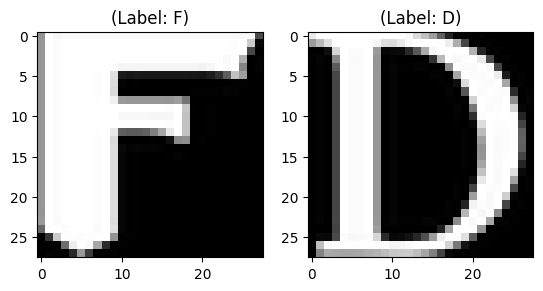

In [6]:
# Display the first image in training data
plt.subplot(121)
curr_img = np.reshape(X_train[0], (28,28))
curr_lbl = train_labels[0]
plt.imshow(curr_img, cmap='gray')
plt.title("(Label: " + str(label_dict[curr_lbl]) + ")")

# Display the first image in testing data
plt.subplot(122)
curr_img = np.reshape(X_test[0], (28,28))
curr_lbl = test_labels[0]
plt.imshow(curr_img, cmap='gray')
plt.title("(Label: " + str(label_dict[curr_lbl]) + ")")

In [7]:
# rescale the data in range 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

## Create a shallow MLP encoder

In [8]:
# STARTING FROM HERE, COMPLETE THE CODE WHERE YOU SEE ...
# size of our encoded representation
encoding_dim = 32  # this is the number of neurons you chose to encode

# define input layer, encoded layer and decoded layer
input_img = Input(shape=(784,))
encoded = Dense(encoding_dim, activation='relu')(input_img)
decoded = Dense(784, activation='softmax')(encoded)

# define autoencoder model 
autoencoder = Model(inputs=input_img, outputs=decoded)
encoder = Model(inputs=input_img, outputs=encoded)

# create a placeholder for an encoded (32-dimensional) input
encoded_input = Input(shape=(encoding_dim,))
 
# retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]

# create the decoder model
decoder = Model(inputs=encoded_input, outputs=decoder_layer(encoded_input))

E0000 00:00:1778939332.679729  285508 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778939332.680144  293720 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778939332.698472  285508 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

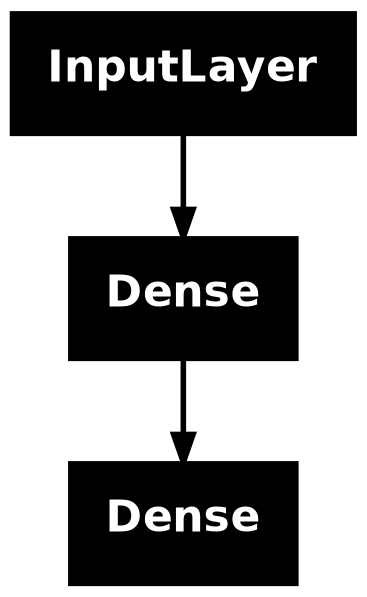

In [31]:
from tensorflow.keras.utils import plot_model

# compile the network
autoencoder.compile(optimizer='rmsprop', loss='binary_crossentropy')

autoencoder.summary()

plot_model(autoencoder, to_file='autoencoder.png')

In [11]:
# for visualiztion
def plot_result(x_test,decoded_imgs):
    n = 10
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # display original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # display reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.show()

In [12]:
X_train_flat = X_train.reshape(60000,784)
X_test_flat = X_test.reshape(10000,784)

An autoencoder's goal is to reconstruct its input, not predict labels. So:

Target = Input: Use X_train_flat as both input and target.

Loss Function: Use mse (Mean Squared Error) or binary_crossentropy (if pixel values are normalized to [0, 1]).

Remove Labels: Do not use Y_train or Y_test.


In [32]:
# train the network
B=128
E=20

log = autoencoder.fit(
    X_train_flat, X_train_flat,  # Input and target are the same
    batch_size=B,
    epochs=E,
    verbose=1,
    validation_data=(X_test_flat, X_test_flat)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0019 - loss: 0.2142 - val_accuracy: 0.0015 - val_loss: 0.1902
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0018 - loss: 0.2136 - val_accuracy: 0.0010 - val_loss: 0.1926
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0018 - loss: 0.2133 - val_accuracy: 0.0013 - val_loss: 0.1905
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0018 - loss: 0.2130 - val_accuracy: 0.0013 - val_loss: 0.2103
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0018 - loss: 0.2127 - val_accuracy: 0.0011 - val_loss: 0.1955
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0017 - loss: 0.2126 - val_accuracy: 0.0019 - val_loss: 0.1908
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0018 - loss: 0.2124 - val_accuracy: 0.0017 - val_loss: 0.1924
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0018 - loss: 0.2122 - val_accuracy: 0.

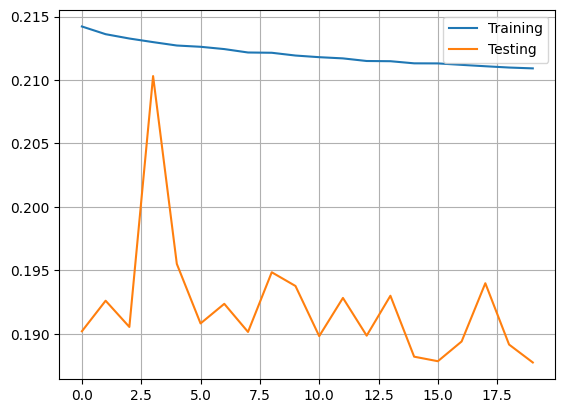

In [33]:
plt.plot(log.history['loss'], label='Training')
plt.plot(log.history['val_loss'], label='Testing')
plt.legend()
plt.grid()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step


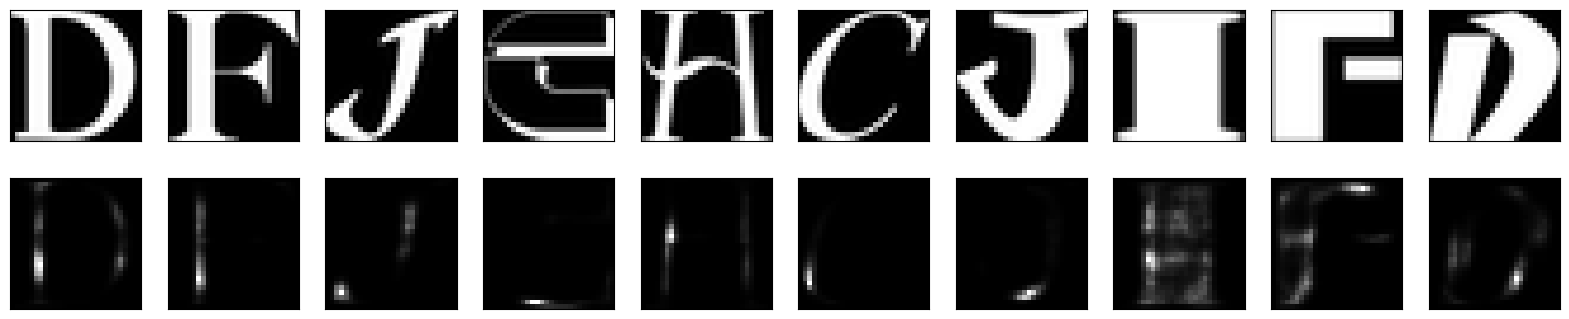

In [34]:
# encode and decode some digits
# note that we take them from the *test* set
encoded_imgs = encoder.predict(X_test_flat)
decoded_imgs = decoder.predict(encoded_imgs)
plot_result(X_test_flat,decoded_imgs)

### Use the encoded features to train another classifier

In [35]:
X_train_feat = encoder.predict(X_train_flat)
X_test_feat = encoder.predict(X_test_flat)

# Normalization (standardization) of training and test sets
scaler = StandardScaler()  
scaler.fit(X_train_feat)
X_train_feat = scaler.transform(X_train_feat)  
X_test_feat = scaler.transform(X_test_feat)

print(X_train_feat.shape)
print(Y_train.shape)
print(X_test_feat.shape)
print(Y_test.shape)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 741us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step
(60000, 32)
(60000, 10)
(10000, 32)
(10000, 10)


In [36]:
# using the features
clf = SVC(kernel='linear', cache_size=7000)
clf.fit(X_train_feat, train_labels)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",7000
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [37]:
y_pred = clf.predict(X_test_feat)

# Print classification results with confusion matrix
print("Classification report for classifier %s:\n%s\n" %
      (clf, metrics.classification_report(test_labels, y_pred)))
print("\nConfusion matrix:\n%s" % metrics.confusion_matrix(test_labels, y_pred))

Classification report for classifier SVC(cache_size=7000, kernel='linear'):
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1000
           1       0.90      0.87      0.88      1000
           2       0.91      0.92      0.91      1000
           3       0.92      0.90      0.91      1000
           4       0.90      0.87      0.89      1000
           5       0.90      0.93      0.91      1000
           6       0.88      0.88      0.88      1000
           7       0.91      0.89      0.90      1000
           8       0.88      0.85      0.87      1000
           9       0.87      0.93      0.90      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



Confusion matrix:
[[906   5   3  10   3   1  10  29  14  19]
 [ 13 872   7  23  16  11  15  12  11  20]
 [  4   3 916   5  25  12  21   4   9   1]
 [  9  25  10 90

## Create a conv de-noising autoencoder

In [ ]:
input_img = Input(shape=(28, 28, 1)) # grey
# encoder
conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img) #28 x 28 x 32
pool1 = MaxPooling2D((2, 2), padding='same')(conv1) #14 x 14 x 32
conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1) #14 x 14 x 64
pool2 = MaxPooling2D((2, 2), padding='same')(conv2) #7 x 7 x 64
conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2) #7 x 7 x 128 (small and thick)
encoder = conv3
# decoder
conv4 = Conv2D(128, (3, 3), activation='relu', padding='same')(encoder) #7 x 7 x 128
up1 = UpSampling2D((2, 2))(conv4) # 14 x 14 x 128 (UpSampling2D())
conv5 = Conv2D(64, (3, 3), activation='relu', padding='same')(up1) # 14 x 14 x 64
up2 = UpSampling2D((2, 2))(conv5) # 28 x 28 x 64
conv6 = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(up2)
decoder = conv6 # 28 x 28 x 1
# autoencoder
autoencoder = Model(inputs=input_img, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,625 (1.20 MB)

 Trainable params: 314,625 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
log = autoencoder.fit(X_train, X_train,  # Autoencoders use input as target
    batch_size=128,
    epochs=10,
    verbose=1,
    validation_data=(X_test, X_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 119s 251ms/step - loss: 0.1811 - val_loss: 0.1350
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 250ms/step - loss: 0.1434 - val_loss: 0.1263
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 121s 257ms/step - loss: 0.1382 - val_loss: 0.1235
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 257ms/step - loss: 0.1352 - val_loss: 0.1216
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 121s 258ms/step - loss: 0.1332 - val_loss: 0.1205
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 255ms/step - loss: 0.1318 - val_loss: 0.1191
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 121s 257ms/step - loss: 0.1307 - val_loss: 0.1185
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 248ms/step - loss: 0.1299 - val_loss: 0.1179
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 197ms/step - loss: 0.1292 - val_loss: 0.1174
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 207ms/step - loss: 0.1286 - val_loss: 0.1172


### Predict on test data

In [42]:
decoded_imgs = autoencoder.predict(X_test, verbose=1)
print(decoded_imgs.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
(10000, 28, 28, 1)


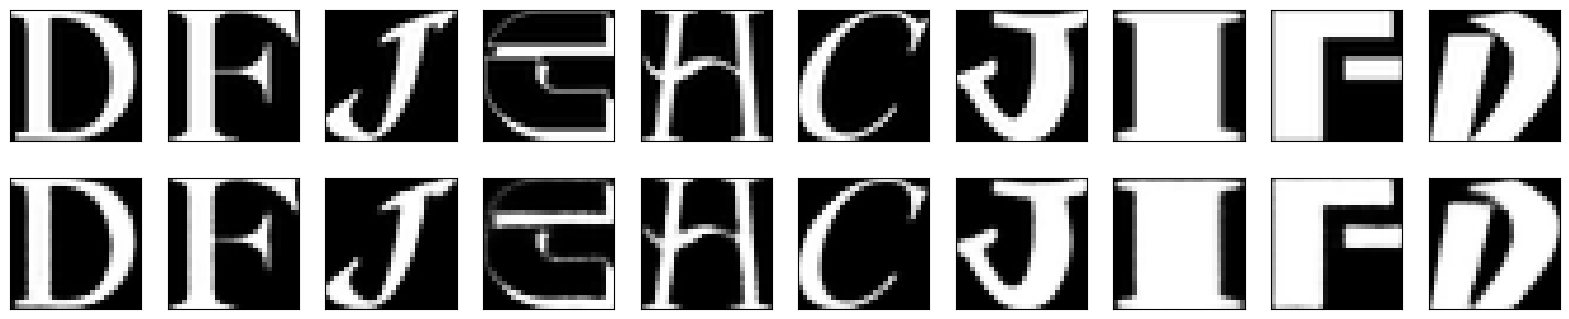

In [43]:
plot_result(X_test_flat,decoded_imgs)

## Denoising autoencoder
First add some noise.

In [44]:
noise_factor = 0.4 #chose a noise factor between 0.0 and 1.0
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

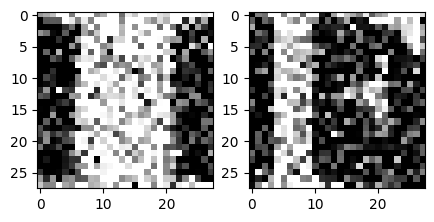

In [45]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
curr_img = np.reshape(X_train_noisy[1], (28,28))
plt.imshow(curr_img, cmap='gray')

# Display the first image in testing data
plt.subplot(122)
curr_img = np.reshape(X_test_noisy[1], (28,28))
plt.imshow(curr_img, cmap='gray')

#### REDEFINE HERE A CONV AUTOENCODER FOR THE DENOISING WITH A SIMILAR ARCHITECTURE
The model is trained on noisy inputs but targets the clean (original) images.

In [46]:
input_shape = (28, 28, 1)
input_layer = Input(shape=input_shape)

### Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
x = MaxPooling2D((2, 2), padding='same')(x)  # 14x14x32
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # 7x7x64
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)  # 7x7x128
encoded = x

### Decoder
x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)  # 7x7x128
x = UpSampling2D((2, 2))(x)  # 14x14x128
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)  # 14x14x64
x = UpSampling2D((2, 2))(x)  # 28x28x64
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)  # 28x28x1

### Build the Denoising Autoencoder
denoising_autoencoder = Model(input_layer, decoded)
denoising_autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,625 (1.20 MB)

 Trainable params: 314,625 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# train on the noisy images and use as target the original clean images
log = autoencoder.fit(X_train_noisy, X_train, batch_size=128, epochs=1,
                        verbose=1, validation_data=(X_test_noisy, X_test))

469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 236ms/step - loss: 0.2790 - val_loss: 0.1721


In [48]:
decoded_imgs = autoencoder.predict(X_test_noisy, verbose=1)
print(decoded_imgs.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
(10000, 28, 28, 1)


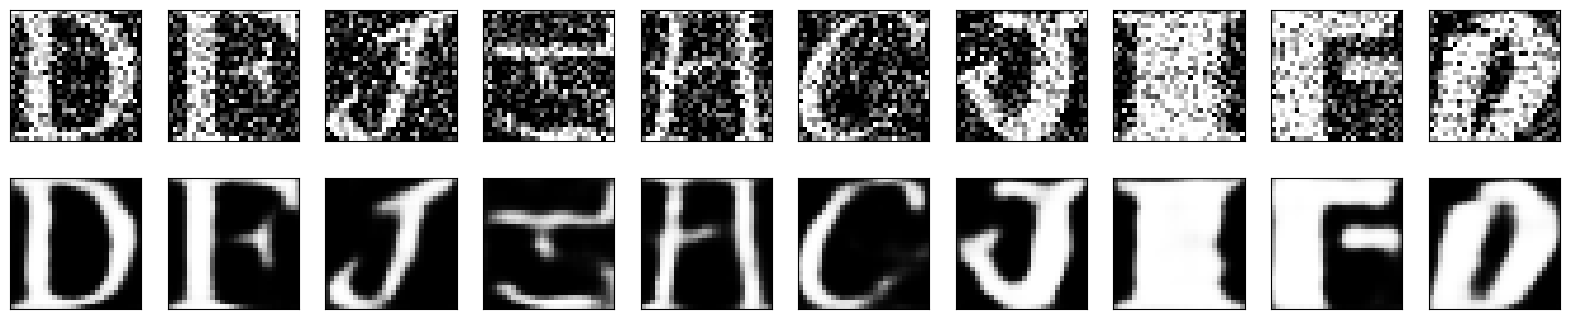

In [49]:
plot_result(X_test_noisy,decoded_imgs)